# Maximum coastal flood depth per municipality

For each coastal municipality and each return-period (RP) flood raster this notebook:

1. finds the **maximum flood depth** and **where** it occurs,
2. plots the depth–RP curves per municipality,
3. looks up the **land cover class** at the location of the maximum depth, and
4. builds a summary table (`Municipality`, `RP_<n>_FD`, `coords_max_dep`, `LC_class`).

**Sections:** 1 Setup & configuration · 2 Load municipalities · 3 Max depth & location · 4 RP curves · 5 Land cover · 6 Summary table

## 1. Setup & configuration

In [64]:
import re
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from matplotlib.lines import Line2D
from pyproj import Transformer
from rasterio.mask import mask

In [ ]:
# ── Which study area to run ──────────────────────────────────────────────
AREA = "albay"   # "quezon" or "albay"

AREAS = {
    "quezon": {
        "prefix": "QUE",
        "scenario_label": "Historical+Synthetic",
        "municipalities_shp": r"F:\SHIELD-SS\[SHIELD-SS] Datasets\Shapefiles\Quezon_municip.shp",
        "raster_dir": r"F:\Cleaned_rasters_Quezon_1",            # merged synthetic + historical
        # "raster_dir": r"d:\Preliminary_TIFFs\Quezon_historical",  # historical only
        # Coastal municipalities, split by coast (used for plot markers).
        # Names must match the shapefile's ADM3_EN values exactly.
        "east": [
            "Sariaya", "Lucena City (Capital)", "Pagbilao", "Padre Burgos", "Agdangan",
            "Unisan", "Pitogo", "Macalelon", "General Luna", "Catanauan",
            "Mulanay", "San Francisco (Aurora)", "San Andres", "San Narciso", "Buenavista",
            "Guinayangan", "Tagkawayan",
        ],
        "west": [
            "Calauag", "Lopez", "Gumaca", "Plaridel", "Atimonan",
            "Mauban", "Real", "Infanta", "General Nakar", "Perez", "Alabat", "Quezon", "Polillo",
            "Panukulan", "Burdeos", "Patnanungan", "Jomalig",
        ],
    },
    "albay": {
        "prefix": "ALB",
        "scenario_label": "Historical+Synthetic",
        "municipalities_shp": r"F:\SHIELD-SS\[SHIELD-SS] Datasets\Shapefiles\Muncips_albay.shp",
        "raster_dir": r"F:\Preliminary_TIFFs\Albay_syn_hist_merged",   # merged synthetic + historical
        # "raster_dir": r"d:\Preliminary_TIFFs\Albay_historical\factor_0.0149_ranked_based\clipped",  # historical only
        # Assumption: every municipality listed here is coastal.
        "east": ["Bacacay", "Legazpi City", "Tiwi", "Tabaco City", "Santo Domingo",
                 "Rapu-Rapu", "Manito", "Malinao", "Malilipot"],
        "west": ["Libon", "Oas", "Pio Duran", "Ligao City"],
    },
}

NAME_COL = "ADM3_EN"                                       # municipality name column in the shapefile
OUTPUT_DIR = Path(r"E:\SHIELD-Storm Surge\analysis")

# ── Land cover (section 5) — SET THESE ───────────────────────────────────
LANDCOVER_SHP = r"E:\SHIELD-Storm Surge\Data\NAMRIA Landcover\Quezon\Shapefiles\LCM_2025_QZN_UTMZ51N_PRS92.shp"   # land cover polygons
LC_FIELD = "LCM_CLASS"                    # attribute column holding the land cover class
LC_LOOKUP = None                               # optional {code: "class name"} if LC_FIELD holds codes
LC_NEAREST_TOL_M = 100                         # if a point falls just outside every polygon, accept the
                                               # nearest one within this distance (m); 0 disables

# ── Plot styling ─────────────────────────────────────────────────────────
FLOOD_CLASSES = [   # (min depth, max depth, colour, label)
    (0.1, 0.6, "#4b4fa3", "Knee-deep"),                # ~10–50 cm
    (0.6, 1.0, "#a6cee3", "Waist-deep"),               # ~60–100 cm
    (1.0, 1.6, "#ffffbf", "Standing height"),          # ~1.1–1.6 m
    (1.6, 2.4, "#f4a261", "Ceiling height"),           # ~1.7–2.4 m
    (2.4, 4.5, "#b1123b", "2 Storey house height"),    # ~2.5–4.5 m
    (4.5, 10,  "#7f0000", "Above 2 storey height"),    # >4.5 m
]

THRESHOLDS = [0.50, 1.00, 1.61, 2.41]                  # dashed guide lines (as in the original notebook)
REGION_MARKERS = {"East": "o", "West": "s"}

## 2. Load municipalities

In [66]:
cfg = AREAS[AREA]
east, west = cfg["east"], cfg["west"]
coastal_munis = east + west
region_of = {**{m: "East" for m in east}, **{m: "West" for m in west}}

muni = gpd.read_file(cfg["municipalities_shp"])

# Catch name mismatches (e.g. "Lucena" vs "Lucena City (Capital)") instead of silently dropping them
not_found = sorted(set(coastal_munis) - set(muni[NAME_COL]))
if not_found:
    print("⚠️  Listed as coastal but NOT found in the shapefile:", not_found)

coastal = muni[muni[NAME_COL].isin(coastal_munis)].copy()
print(f"{len(coastal)} of {len(muni)} municipalities selected as coastal")

DataSourceError: F:\SHIELD-SS\[SHIELD-SS] Datasets\Shapefiles\Municips_albay.shp: No such file or directory

## 3. Maximum flood depth and its location

One pass per raster and municipality. Pixels that are nodata, NaN or ≤ 0 are ignored, so a municipality with no flooding gets `max_flood = 0` and no coordinates.
Coordinates are stored both in the raster CRS (`x_max`, `y_max`) and as WGS84 (`lon`, `lat`).

In [ ]:
def rp_from_name(path):
    """RP_01000.tif -> 1000"""
    m = re.search(r"RP_(\d+)", Path(path).name)
    if m is None:
        raise ValueError(f"Cannot read return period from file name: {path}")
    return int(m.group(1))


def max_depth_and_location(src, geom):
    """Max depth inside `geom` and the pixel-centre (x, y) where it occurs, in the raster CRS.

    Returns None if the geometry misses the raster or has no flooded pixels.
    """
    try:
        clipped, transform = mask(src, [geom], crop=True, filled=False)
    except ValueError:                       # geometry does not overlap the raster
        return None

    arr = np.ma.filled(clipped[0].astype("float64"), np.nan)
    if src.nodata is not None:
        arr[arr == src.nodata] = np.nan
    arr[~np.isfinite(arr) | (arr <= 0)] = np.nan
    if np.isnan(arr).all():
        return None

    row, col = np.unravel_index(np.nanargmax(arr), arr.shape)
    x, y = transform * (col + 0.5, row + 0.5)
    return float(arr[row, col]), x, y

In [ ]:
raster_files = sorted(Path(cfg["raster_dir"]).glob("*.tif"), key=rp_from_name)
print(f"Found {len(raster_files)} cleaned rasters.")

records = []
for raster_path in raster_files:
    print(f"Processing raster: {raster_path.name}")
    rp = rp_from_name(raster_path)

    with rasterio.open(raster_path) as src:
        to_wgs84 = Transformer.from_crs(src.crs, "EPSG:4326", always_xy=True)
        coastal_r = coastal.to_crs(src.crs)               # match municipalities to raster CRS

        for name, geom in zip(coastal_r[NAME_COL], coastal_r.geometry):
            hit = max_depth_and_location(src, geom)
            if hit is None:
                depth, x, y, lon, lat = 0.0, np.nan, np.nan, np.nan, np.nan
            else:
                depth, x, y = hit
                lon, lat = to_wgs84.transform(x, y)
            records.append({
                "raster": raster_path.name, "municipality": name, "return_period": rp,
                "max_flood": depth, "x_max": x, "y_max": y, "lon": lon, "lat": lat,
            })

results = pd.DataFrame(records)          # every coastal municipality x every RP (zeros kept)
results.head()

Found 15 cleaned rasters.
Processing raster: RP_00001.tif
Processing raster: RP_00002.tif
Processing raster: RP_00005.tif
Processing raster: RP_00010.tif
Processing raster: RP_00015.tif
Processing raster: RP_00025.tif
Processing raster: RP_00050.tif
Processing raster: RP_00075.tif
Processing raster: RP_00100.tif
Processing raster: RP_00150.tif
Processing raster: RP_00200.tif
Processing raster: RP_00250.tif
Processing raster: RP_00500.tif
Processing raster: RP_00750.tif
Processing raster: RP_01000.tif


,raster,municipality,return_period,max_flood,x_max,y_max,lon,lat
0,RP_00001.tif,Agdangan,1,0.232973,383535.0,1531895.0,121.922260,13.854481
1,RP_00001.tif,Alabat,1,2.499973,391165.0,1568055.0,121.991431,14.181688
2,RP_00001.tif,Atimonan,1,1.578091,390605.0,1545545.0,121.987139,13.978165
3,RP_00001.tif,Buenavista,1,0.466990,446975.0,1522185.0,122.509478,13.768565
4,RP_00001.tif,Burdeos,1,1.322949,399025.0,1642625.0,122.061424,14.856126


## 4. Depth–return period curves

In [ ]:
def plot_rp_curves(df, cfg, region_markers=True, save_path=None):
    """Max flood depth vs return period, one line per municipality (equal spacing on the x-axis)."""
    rp_order = sorted(df["return_period"].unique())
    x_of = {rp: i for i, rp in enumerate(rp_order)}
    munis = sorted(df["municipality"].unique())
    colors = dict(zip(munis, sns.color_palette("tab10", n_colors=len(munis))))
    ymax = np.ceil(df["max_flood"].max()) + 0.5

    fig, ax = plt.subplots(figsize=(18, 9))
    fig.subplots_adjust(right=0.72)

    # background flood-depth bands + labels
    for lo, hi, color, label in FLOOD_CLASSES:
        ax.axhspan(lo, hi, facecolor=color, alpha=0.18, zorder=0)
        ax.text(len(rp_order) - 1, (lo + min(hi, ymax)) / 2, label,
                va="center", ha="right", fontsize=9, alpha=0.8)
        
    for t in THRESHOLDS:
        ax.axhline(t, color="black", linestyle="--", linewidth=0.8, alpha=0.6, zorder=1)

    for muni_name in munis:
        d = df[df["municipality"] == muni_name].sort_values("return_period")
        marker = REGION_MARKERS.get(region_of.get(muni_name), "o") if region_markers else "o"
        ax.plot(d["return_period"].map(x_of), d["max_flood"], label=muni_name,
                marker=marker, markersize=7, markeredgecolor="white", markeredgewidth=0.8,
                linewidth=2.5, color=colors[muni_name], zorder=3)

    ax.set_title(f"Maximum Coastal Flood per Municipality Across Return Periods ({cfg['scenario_label']})", pad=20)
    ax.set_xlabel("Return Period (years)")
    ax.set_ylabel("Flood Depth (m)")
    ax.set_xticks(list(x_of.values()))
    ax.set_xticklabels(list(x_of.keys()))
    ax.set_ylim(0, ymax)
    ax.grid(True, axis="x", alpha=0.3)

    extra = []
    if region_markers:
        region_legend = ax.legend(
            handles=[Line2D([0], [0], marker=m, color="black", label=r, markerfacecolor="gray", markersize=7)
                     for r, m in REGION_MARKERS.items()],
            title="Location", loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
        ax.add_artist(region_legend)
        extra.append(region_legend)
        muni_anchor = (1.02, 0.62)
    else:
        muni_anchor = (1.02, 1)
    extra.append(ax.legend(title="Municipality", loc="upper left", bbox_to_anchor=muni_anchor, fontsize=8))

    fig.tight_layout(pad=3)
    
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", bbox_extra_artists=extra)
    plt.show()


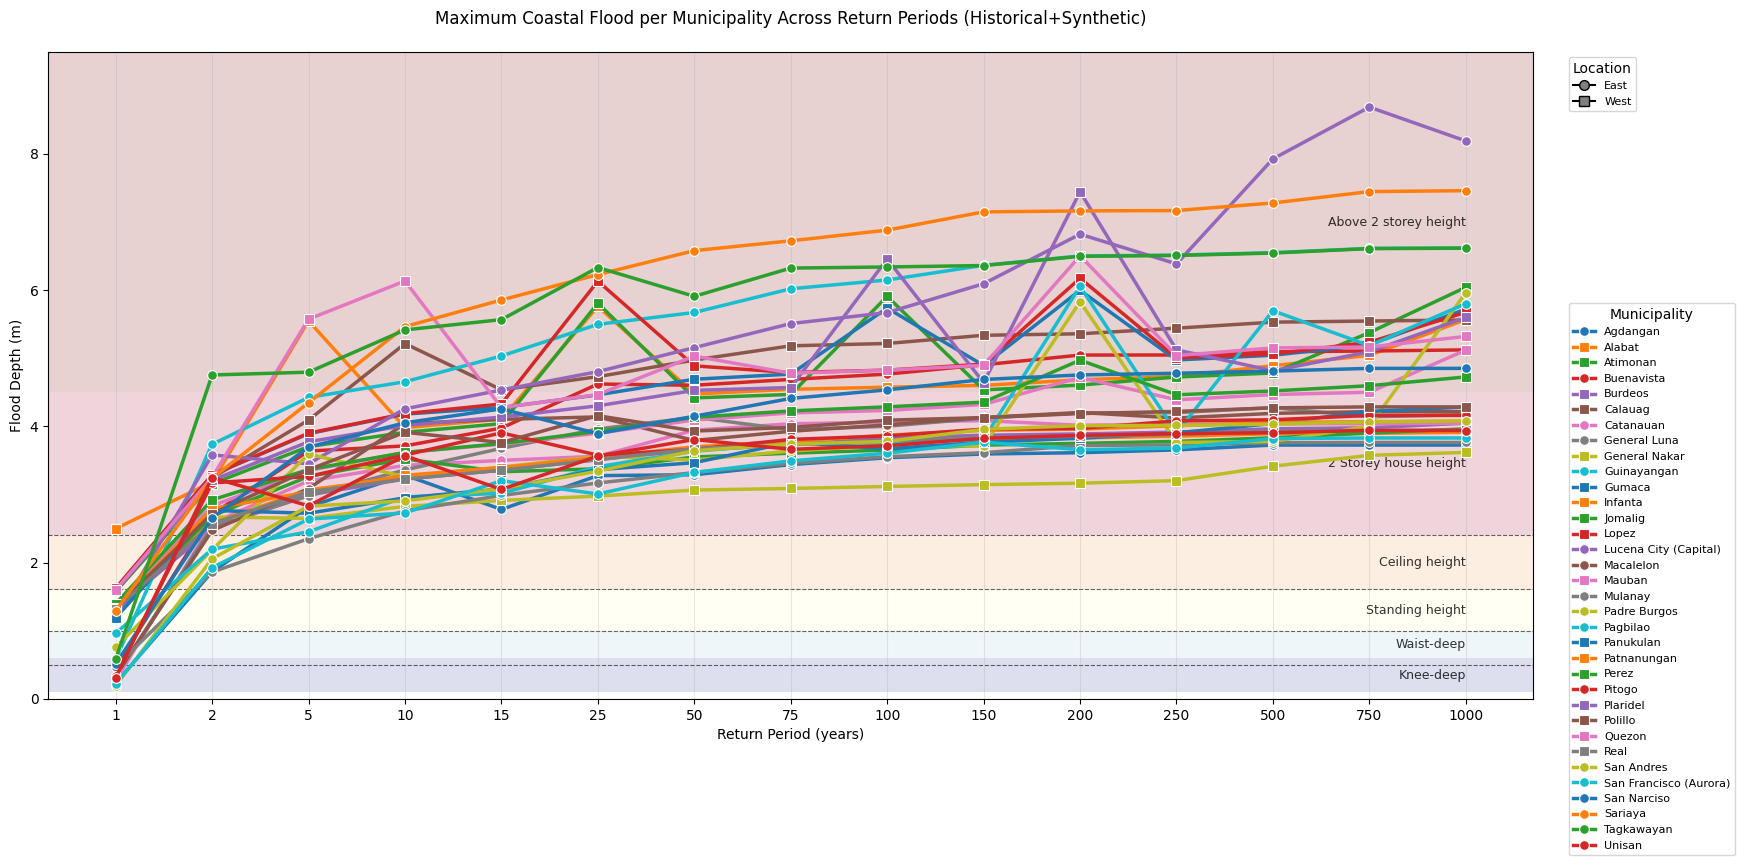

In [ ]:
plot_rp_curves(results, cfg, region_markers=True, save_path=OUTPUT_DIR / f"max_depth_per_municipality_{AREA}.png")

## 5. Land cover at the point of maximum depth

Each (municipality, RP) maximum-depth point is matched to the land cover polygon that contains it.
Points that miss every polygon (e.g. a shoreline pixel) fall back to the nearest polygon within `LC_NEAREST_TOL_M`;
the `LC_match` column records which rule was used.

In [ ]:
def assign_land_cover(points, lc, lc_field, tol_m=0):
    """Return a DataFrame (same index as `points`) with LC_class and LC_match."""
    work_crs = lc.estimate_utm_crs()                       # metric CRS for the nearest-polygon fallback
    pts = points.to_crs(work_crs)
    lc = lc[[lc_field, "geometry"]].to_crs(work_crs)

    out = pd.DataFrame({"LC_class": pd.NA, "LC_match": pd.NA}, index=pts.index, dtype="object")

    # 1) point inside a polygon
    inside = gpd.sjoin(pts, lc, how="left", predicate="within")
    inside = inside[~inside.index.duplicated(keep="first")]
    ok = inside[lc_field].notna()
    out.loc[inside.index[ok], "LC_class"] = inside.loc[ok, lc_field]
    out.loc[inside.index[ok], "LC_match"] = "within"

    # 2) fallback: nearest polygon within tolerance
    todo = out["LC_class"].isna()
    if tol_m and todo.any():
        near = gpd.sjoin_nearest(pts.loc[todo], lc, how="left", max_distance=tol_m, distance_col="dist_m")
        near = near[~near.index.duplicated(keep="first")]
        ok = near[lc_field].notna()
        out.loc[near.index[ok], "LC_class"] = near.loc[ok, lc_field]
        out.loc[near.index[ok], "LC_match"] = "nearest (" + near.loc[ok, "dist_m"].round().astype(int).astype(str) + " m)"
    return out

In [ ]:
lc_path = Path(LANDCOVER_SHP)
if not lc_path.exists():
    raise FileNotFoundError(f"Set LANDCOVER_SHP in section 1 - file not found: {lc_path}")

lc = gpd.read_file(lc_path)
if LC_FIELD not in lc.columns:
    raise KeyError(f"LC_FIELD '{LC_FIELD}' not in land cover shapefile. Available columns: {list(lc.columns)}")
if lc.crs is None:
    raise ValueError("Land cover shapefile has no CRS (missing .prj?)")
lc = lc[lc.geometry.notna() & ~lc.geometry.is_empty]

# one point per (municipality, RP) that has flooding
has_pt = results["lon"].notna()
points = gpd.GeoDataFrame(
    results.loc[has_pt, ["lon", "lat"]],
    geometry=gpd.points_from_xy(results.loc[has_pt, "lon"], results.loc[has_pt, "lat"]),
    crs="EPSG:4326",
)

lc_hits = assign_land_cover(points, lc, LC_FIELD, LC_NEAREST_TOL_M)
detail = results.join(lc_hits)

if LC_LOOKUP:
    detail["LC_class"] = detail["LC_class"].map(LC_LOOKUP).fillna(detail["LC_class"])
detail.loc[~has_pt, ["LC_class", "LC_match"]] = ["n/a (no flooding)", "n/a"]
detail["LC_class"] = detail["LC_class"].fillna("No land cover data")
detail["LC_match"] = detail["LC_match"].fillna("none")

print(detail.loc[has_pt, "LC_match"].str.replace(r"\(.*\)", "", regex=True).str.strip().value_counts().to_string())

LC_match
within     455
nearest     55


## 6. Summary table

One row per coastal municipality.

| Column | Meaning |
|---|---|
| `Municipality` | coastal municipality name |
| `RP_<n>_FD` | maximum flood depth (m) for the *n*-year return period (0 = no flooding) |
| `coords_max_dep` | `(lon, lat)` in WGS84 of the **highest depth across all return periods** |
| `LC_class` | land cover class at that location |

`detail` (below) holds the same information for every municipality × return period, i.e. the coordinates and land cover of each RP's own maximum.

In [ ]:
# Max depth per RP, one column each (RP_1_FD, RP_2_FD, ...)
fd = results.pivot(index="municipality", columns="return_period", values="max_flood").sort_index(axis=1)
fd.columns = [f"RP_{rp}_FD" for rp in fd.columns]
rp_cols = list(fd.columns)

# Location + land cover of each municipality's overall maximum (highest depth over all RPs)
peak = detail.loc[detail.groupby("municipality")["max_flood"].idxmax()].set_index("municipality")
peak["coords_max_dep"] = [
    (round(lo, 5), round(la, 5)) if pd.notna(lo) else None for lo, la in zip(peak["lon"], peak["lat"])
]

summary = (
    fd.round(2)
      .join(peak[["coords_max_dep", "LC_class"]])
      .rename_axis("Municipality")
      .reset_index()
)[["Municipality", *rp_cols, "coords_max_dep", "LC_class"]]

summary

,Municipality,RP_1_FD,RP_2_FD,RP_5_FD,RP_10_FD,RP_15_FD,RP_25_FD,RP_50_FD,RP_75_FD,RP_100_FD,RP_150_FD,RP_200_FD,RP_250_FD,RP_500_FD,RP_750_FD,RP_1000_FD,coords_max_dep,LC_class
0,Agdangan,0.23,1.87,2.82,3.29,2.78,3.28,3.29,3.44,3.54,3.60,3.61,3.66,3.73,3.73,3.73,"(121.94873, 13.85179)",Perennial Crop
1,Alabat,2.50,3.18,5.55,3.98,4.11,5.76,4.48,4.55,4.58,4.60,4.68,4.73,4.89,5.04,5.57,"(122.04995, 14.07986)",Fishpond
2,Atimonan,1.58,3.16,3.70,3.91,4.04,5.81,4.42,4.47,5.91,4.54,4.61,4.73,4.78,5.38,6.04,"(121.95638, 13.98274)",Perennial Crop
3,Buenavista,0.47,2.71,3.64,3.71,3.98,4.62,4.60,4.69,4.77,4.90,5.05,5.05,5.10,5.11,5.12,"(122.50717, 13.76711)",Perennial Crop
4,Burdeos,1.32,2.50,2.99,3.23,3.36,3.52,3.65,3.73,3.83,3.87,3.89,3.92,3.96,3.98,4.05,"(121.95171, 14.96024)",Perennial Crop
5,Calauag,1.58,3.25,4.09,5.22,4.54,4.73,4.97,5.18,5.22,5.34,5.36,5.44,5.53,5.55,5.56,"(122.32129, 14.03484)",Mangrove Forest
6,Catanauan,0.27,2.58,3.20,3.43,3.50,3.56,3.95,4.04,4.06,4.09,4.02,4.03,4.04,4.04,4.05,"(122.27791, 13.59774)",Fishpond
7,General Luna,0.33,2.53,2.98,3.36,3.68,3.96,4.13,3.95,4.00,4.12,4.20,4.20,4.28,4.14,4.17,"(122.16335, 13.7113)",Fishpond
8,General Nakar,1.29,2.67,2.65,2.83,2.91,2.98,3.07,3.09,3.12,3.15,3.17,3.20,3.42,3.58,3.62,"(121.44423, 15.20473)",Perennial Crop
9,Guinayangan,0.58,3.74,4.43,4.66,5.03,5.50,5.67,6.02,6.15,6.37,6.50,6.52,6.55,6.61,6.62,"(122.41858, 13.9417)",Fishpond


In [ ]:
# Per municipality x RP detail (coordinates + land cover of every RP's maximum)
detail_table = detail.rename(columns={"municipality": "Municipality"})[
    ["Municipality", "return_period", "max_flood", "lon", "lat", "LC_class", "LC_match"]
].sort_values(["Municipality", "return_period"])

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
summary.to_csv(OUTPUT_DIR / f"{cfg['prefix']}-max_flood_summary.csv", index=False)
detail_table.to_csv(OUTPUT_DIR / f"{cfg['prefix']}-max_flood_detail_by_rp.csv", index=False)
detail_table.head(10)

,Municipality,return_period,max_flood,lon,lat,LC_class,LC_match
0,Agdangan,1,0.232973,121.922260,13.854481,Perennial Crop,within
34,Agdangan,2,1.867507,121.948735,13.851793,Perennial Crop,nearest (9 m)
68,Agdangan,5,2.820240,121.928086,13.855049,Fishpond,within
102,Agdangan,10,3.285240,121.917504,13.862325,Fishpond,within
136,Agdangan,15,2.781761,121.917053,13.859882,Fishpond,within
170,Agdangan,25,3.277934,121.917053,13.859882,Fishpond,within
204,Agdangan,50,3.290951,121.924109,13.854670,Perennial Crop,within
238,Agdangan,75,3.439777,121.924109,13.854670,Perennial Crop,within
272,Agdangan,100,3.540236,121.948735,13.851793,Perennial Crop,nearest (9 m)
306,Agdangan,150,3.595577,121.948735,13.851793,Perennial Crop,nearest (9 m)
